In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create images folder if it doesn't exist
os.makedirs('images', exist_ok=True)

# Set a professional plotting style
sns.set(style="whitegrid")

In [2]:
# Load the dataset
df = pd.read_csv('dataset/titanic.csv')

# Display first 5 rows
print(df.head())

# Check data types and missing values
print(df.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


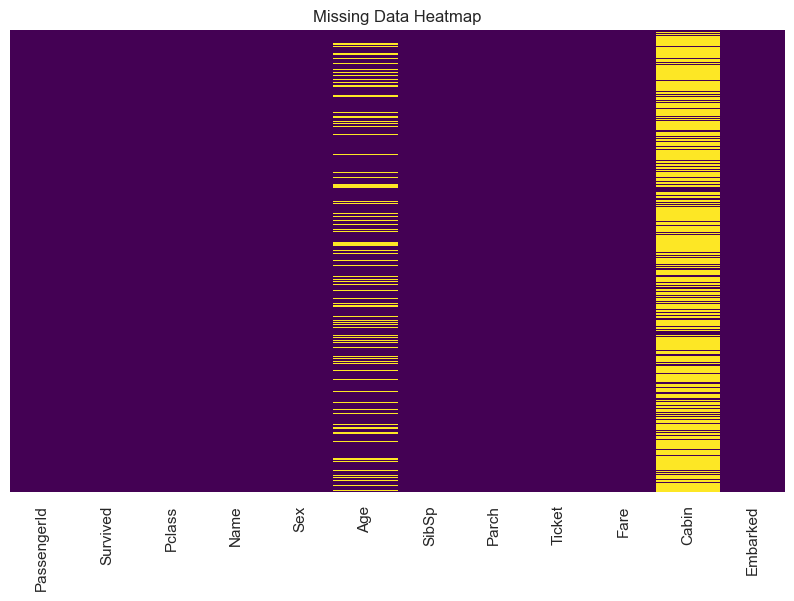

Data Cleaned!


C:\Users\Abin\AppData\Local\Temp\ipykernel_23824\1070956590.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [3]:
# Check for missing values
print(df.isnull().sum())

# Visualization of missing values using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.savefig('images/missing_data.png')
plt.show()

# Strategy: Fill missing Age with the median age
df['Age'].fillna(df['Age'].median(), inplace=True)

# Drop 'Cabin' column (too many missing values)
df.drop('Cabin', axis=1, inplace=True)

# Drop any remaining rows with missing values (like Embarked)
df.dropna(inplace=True)

print("Data Cleaned!")

C:\Users\Abin\AppData\Local\Temp\ipykernel_23824\1905634601.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='pastel')


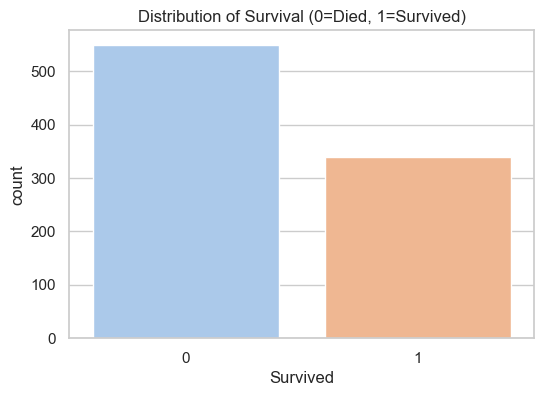

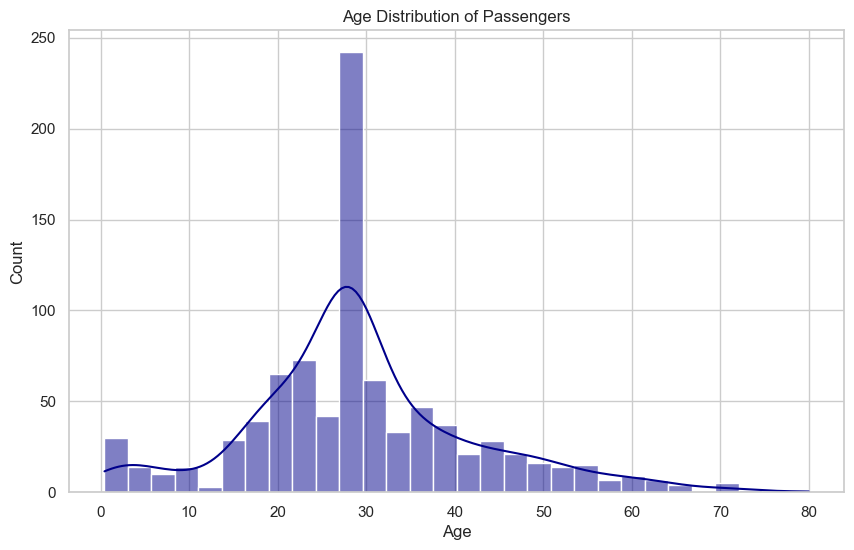

In [4]:
# 1. Distribution of Survival (Target Variable)
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df, palette='pastel')
plt.title('Distribution of Survival (0=Died, 1=Survived)')
plt.savefig('images/survival_count.png')
plt.show()

# 2. Age Distribution (Histogram) - Required by PDF
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, bins=30, color='darkblue')
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.savefig('images/age_distribution.png')
plt.show()

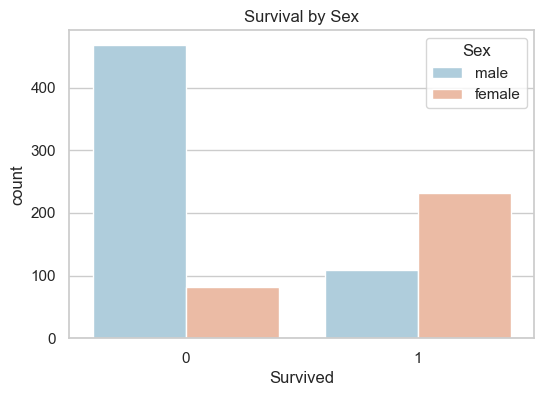

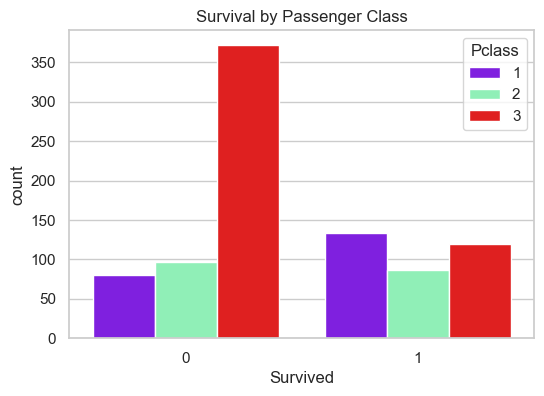

In [5]:
# 1. Survival by Sex
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', hue='Sex', data=df, palette='RdBu_r')
plt.title('Survival by Sex')
plt.savefig('images/survival_by_sex.png')
plt.show()

# 2. Survival by Passenger Class
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', hue='Pclass', data=df, palette='rainbow')
plt.title('Survival by Passenger Class')
plt.savefig('images/survival_by_class.png')
plt.show()

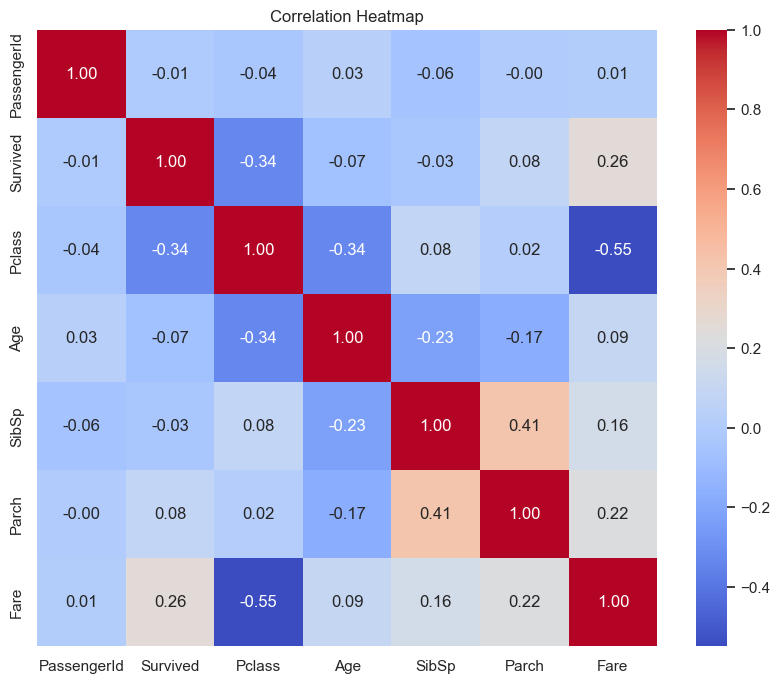

In [6]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

# Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.savefig('images/correlation_heatmap.png')
plt.show()

C:\Users\Abin\AppData\Local\Temp\ipykernel_23824\3091689397.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Age', data=df, palette='winter')


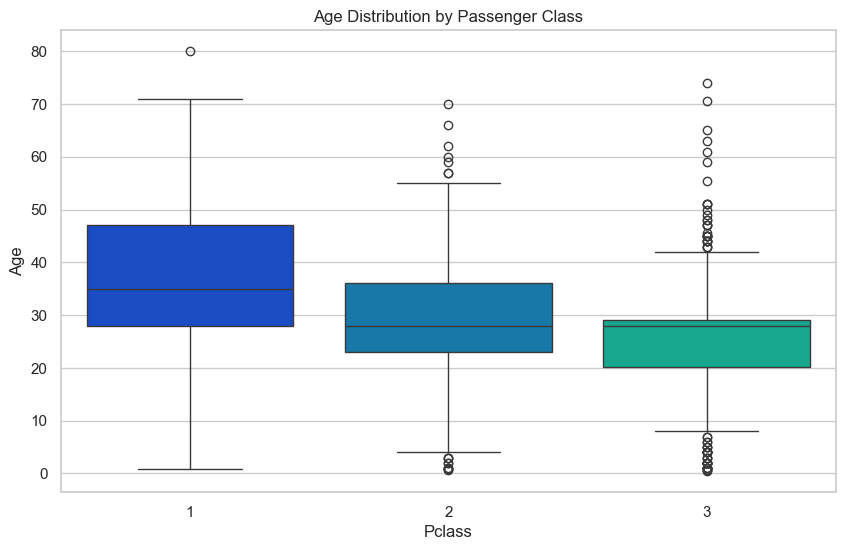

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Pclass', y='Age', data=df, palette='winter')
plt.title('Age Distribution by Passenger Class')
plt.savefig('images/age_by_class.png')
plt.show()

Survival Rate by Class:
Pclass
1    62.616822
2    47.282609
3    24.236253
Name: Survived, dtype: float64


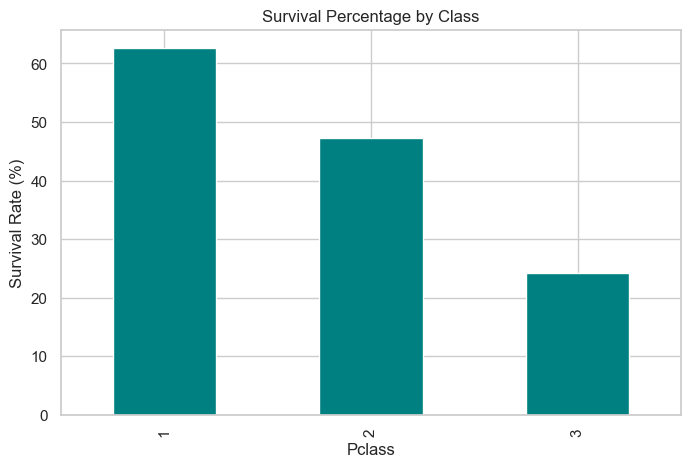

In [8]:
# Calculate survival rate per class
survival_rate = df.groupby('Pclass')['Survived'].mean() * 100
print("Survival Rate by Class:")
print(survival_rate)

# Plot
survival_rate.plot(kind='bar', color='teal', figsize=(8,5))
plt.ylabel('Survival Rate (%)')
plt.title('Survival Percentage by Class')
plt.savefig('images/survival_rate_calc.png')
plt.show()

<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
C:\Users\Abin\AppData\Local\Temp\ipykernel_23824\4166814911.py:2: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
C:\Users\Abin\AppData\Local\Temp\ipykernel_23824\4166814911.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Title', y='Survived', data=df, palette='muted')


Title
Mr          517
Miss        181
Mrs         124
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


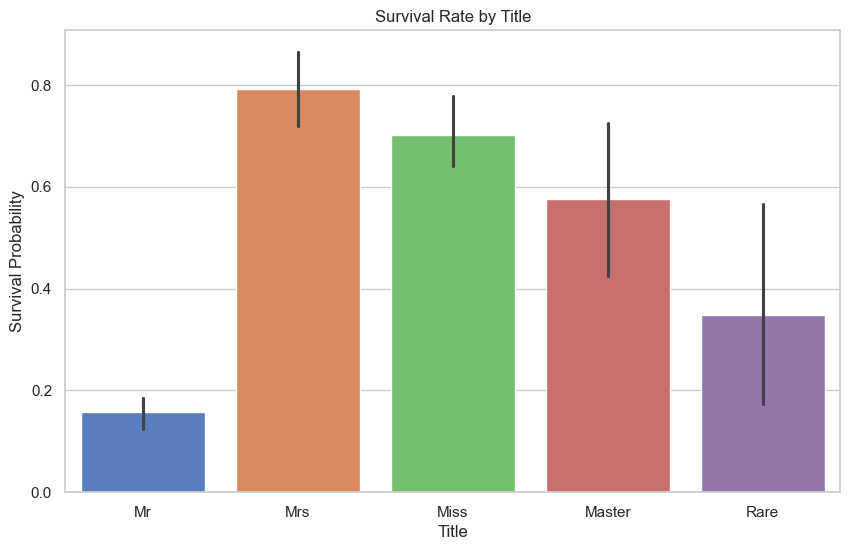

In [10]:
# Extract Title from Name using Regex
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Check the counts of each title
print(df['Title'].value_counts())

# Group rare titles (Dr, Rev, Major, etc.) into 'Rare'
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col', \
 	'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# Plot Survival by Title
plt.figure(figsize=(10, 6))
sns.barplot(x='Title', y='Survived', data=df, palette='muted')
plt.title('Survival Rate by Title')
plt.ylabel('Survival Probability')
plt.savefig('images/survival_by_title.png')
plt.show()

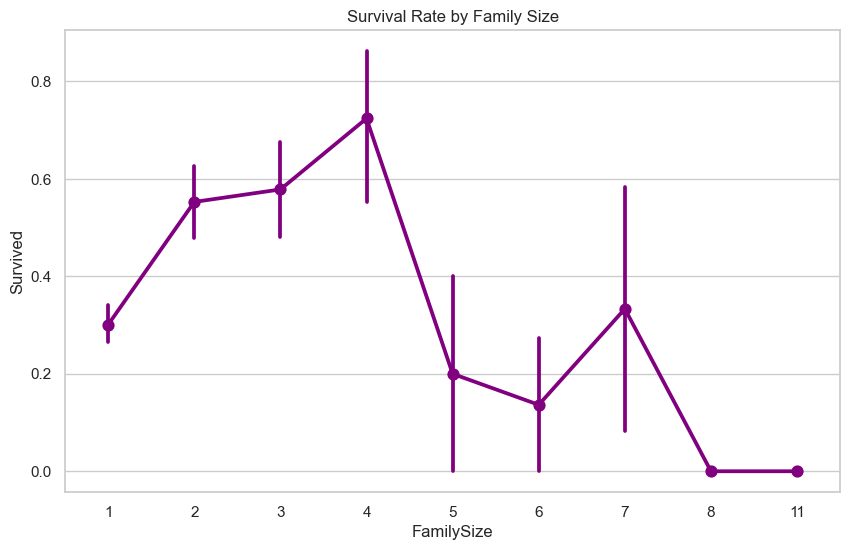

In [11]:
# Create FamilySize column
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 includes the passenger themselves

# Plot Survival by Family Size
plt.figure(figsize=(10, 6))
sns.pointplot(x='FamilySize', y='Survived', data=df, color='purple')
plt.title('Survival Rate by Family Size')
plt.savefig('images/survival_by_familysize.png')
plt.show()

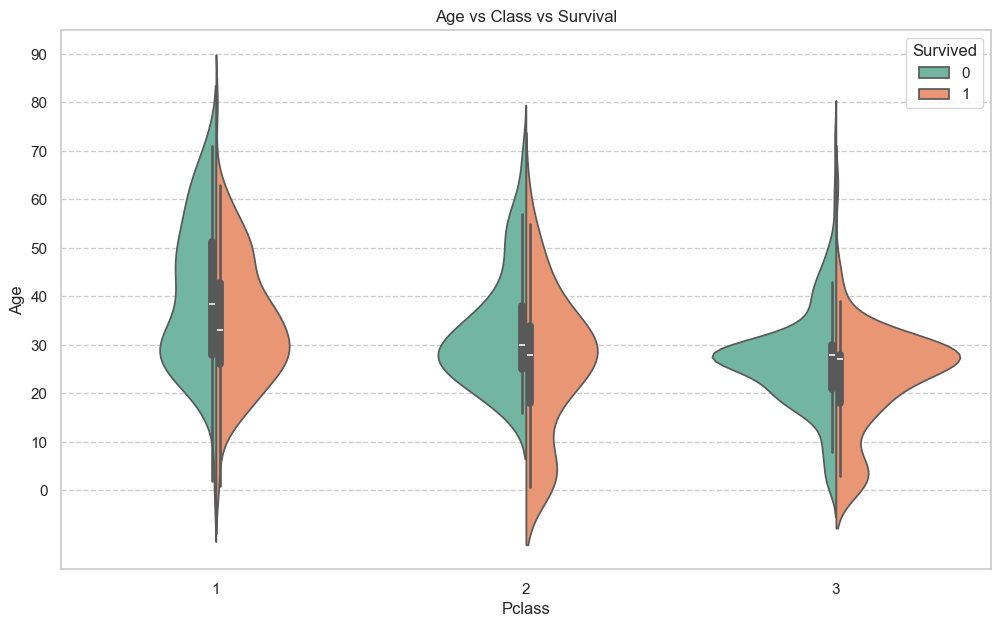

In [12]:
# Violin Plot to show Age distribution by Class and Survival
plt.figure(figsize=(12, 7))
sns.violinplot(x='Pclass', y='Age', hue='Survived', data=df, split=True, palette='Set2')
plt.title('Age vs Class vs Survival')
plt.yticks(range(0, 100, 10))
plt.grid(axis='y', linestyle='--')
plt.savefig('images/age_class_survival_violin.png')
plt.show()

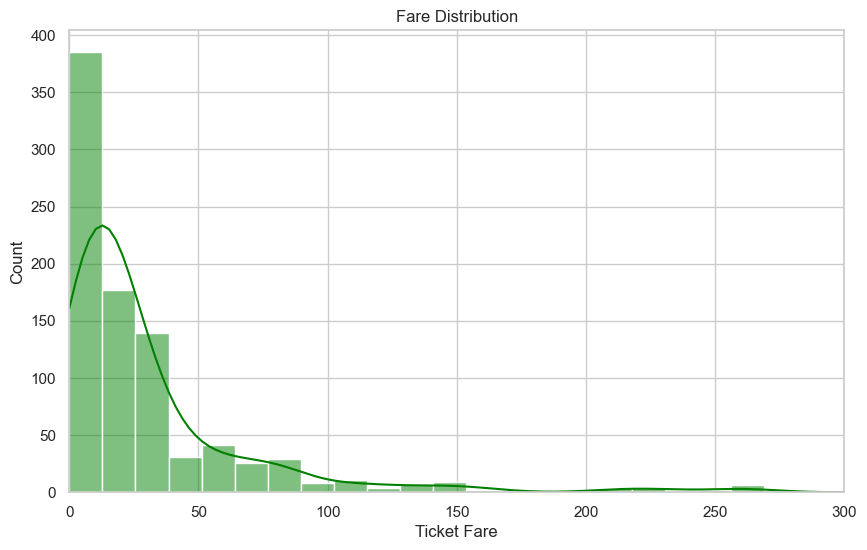

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Fare'], color='green', bins=40, kde=True)
plt.title('Fare Distribution')
plt.xlabel('Ticket Fare')
plt.xlim(0, 300) # Limiting x-axis to remove extreme outliers for better view
plt.savefig('images/fare_distribution.png')
plt.show()